In [3]:
import torch
from torch import nn
from d2l import torch as d2l

In [4]:
def dropout_layer(X,dropout):
    assert 0 <= dropout <= 1
    if dropout == 1:
        return torch.zeros_like(X)
    if dropout == 0:
        return X
    mask = (torch.rand(X.shape) > dropout).float()
    return mask*X / (1.0 - dropout)

In [5]:
## 定义两层MLP
num_inputs,num_outputs,num_hiddens1,num_hiddens2 = 784,10,256,256

In [6]:
## dropout发生在隐藏层之后，dropout rate由低到高
dropout1,dropout2 = 0.2,0.5

In [9]:
class Net(nn.Module):
    def __init__(self, num_inputs, num_outputs,num_hiddens1,num_hiddens2,is_training=True):
        super(Net, self).__init__()
        self.num_inputs = num_inputs
        self.training = is_training
        self.lin1 = nn.Linear(num_inputs, num_hiddens1)
        self.lin2 = nn.Linear(num_hiddens1, num_hiddens2)
        self.lin3 = nn.Linear(num_hiddens2, num_outputs)
        self.relu = nn.ReLU()
    def forward(self,X):
        H1 = self.relu(self.lin1(X.reshape((-1,num_inputs))))
        if self.training == True:
            H1 = dropout_layer(H1,dropout1)
        H2 = self.relu(self.lin2(H1))
        if self.training == True:
            H2 = dropout_layer(H2,dropout2)
        out = self.lin3(H2)
        return out

In [10]:
net = Net(num_inputs,num_outputs,num_hiddens1,num_hiddens2)

In [11]:
import torch
from torch import nn
import torchvision
from torchvision import transforms
import time


class Accumulator:
    """在 n 个变量上累加"""
    def __init__(self, n):
        self.data = [0.0] * n

    def add(self, *args):
        self.data = [a + float(b) for a, b in zip(self.data, args)]

    def reset(self):
        self.data = [0.0] * len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]


def evaluate_accuracy(net, data_iter):
    """计算在指定数据集上模型的精度"""
    if isinstance(net, torch.nn.Module):
        net.eval()
    metric = Accumulator(2)   # 正确预测数、预测总数
    with torch.no_grad():
        for X, y in data_iter:
            metric.add(accuracy(net(X), y), y.numel())
    return metric[0] / metric[1]


def accuracy(y_hat, y):
    """计算预测正确的数量"""
    if len(y_hat.shape) > 1 and y_hat.shape[1] > 1:
        y_hat = y_hat.argmax(axis=1)      # 取最大预测类别
    cmp = y_hat.type(y.dtype) == y
    return float(cmp.type(y.dtype).sum())


def train_epoch_ch3(net, train_iter, loss, updater):
    """训练模型一个迭代周期（分类任务）"""
    if isinstance(net, torch.nn.Module):
        net.train()
    metric = Accumulator(3)   # 训练损失之和、训练准确数之和、样本数
    for X, y in train_iter:
        y_hat = net(X)
        l = loss(y_hat, y)
        if isinstance(updater, torch.optim.Optimizer):
            updater.zero_grad()
            l.mean().backward()
            updater.step()
        else:
            l.sum().backward()
            updater(X.shape[0])
        metric.add(float(l.sum()), accuracy(y_hat, y), y.numel())
    return metric[0] / metric[2], metric[1] / metric[2]


def train_ch3(net, train_iter, test_iter, loss, num_epochs, updater):
    """训练模型（定义见第3章，分类任务版）"""
    animator = d2l.Animator(xlabel='epoch', xlim=[1, num_epochs], ylim=[0.3, 0.9],
                            legend=['train loss', 'train acc', 'test acc'])
    timer, num_batches = d2l.Timer(), len(train_iter)
    for epoch in range(num_epochs):
        metric = Accumulator(3)
        net.train()
        for i, (X, y) in enumerate(train_iter):
            timer.start()
            y_hat = net(X)
            l = loss(y_hat, y)
            if isinstance(updater, torch.optim.Optimizer):
                updater.zero_grad()
                l.mean().backward()
                updater.step()
            else:
                l.sum().backward()
                updater(X.shape[0])
            metric.add(float(l.sum()), accuracy(y_hat, y), y.numel())
            timer.stop()
            # 每 1/5 个 epoch 记录一次
            if (i + 1) % (num_batches // 5) == 0 or i == num_batches - 1:
                animator.add(epoch + (i + 1) / num_batches,
                             (metric[0] / metric[2], metric[1] / metric[2], None))
        test_acc = evaluate_accuracy(net, test_iter)
        animator.add(epoch + 1, (None, None, test_acc))
    print(f'loss {metric[0] / metric[2]:.3f}, train acc '
          f'{metric[1] / metric[2]:.3f}, test acc {test_acc:.3f}')
    print(f'{metric[2] * num_epochs / timer.sum():.1f} examples/sec '
          f'on {str(d2l.try_gpu())}')

loss 0.300, train acc 0.889, test acc 0.846
105357.2 examples/sec on cpu


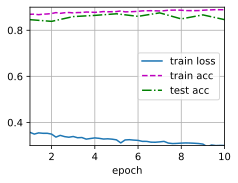

In [13]:
num_epochs, lr, batch_size = 10, 0.5, 256
loss = nn.CrossEntropyLoss(reduction='none')
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)
trainer = torch.optim.SGD(net.parameters(), lr=lr)
train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)

In [15]:
## API version of Dropout
net = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784,256),
    nn.ReLU(),
    nn.Dropout(dropout1),
    nn.Linear(256,256),
    nn.ReLU(),
    nn.Dropout(dropout2),
    nn.Linear(256,10)
)
def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.01)

net.apply(init_weights)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=256, bias=True)
  (2): ReLU()
  (3): Dropout(p=0.2, inplace=False)
  (4): Linear(in_features=256, out_features=256, bias=True)
  (5): ReLU()
  (6): Dropout(p=0.5, inplace=False)
  (7): Linear(in_features=256, out_features=10, bias=True)
)

loss 0.348, train acc 0.872, test acc 0.857
111408.3 examples/sec on cpu


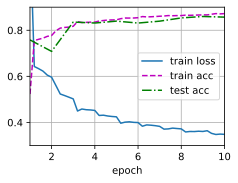

In [16]:
trainer = torch.optim.SGD(net.parameters(), lr=lr)
train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)